# 第6周补充实验报告

在第6周库存优化的基础上，针对反馈进行五个方向的深化实验。

| 方向 | 补充内容 |
|------|----------|
| 一、ABC 分类 | 阈值敏感性分析；按品类差异化分类 |
| 二、安全库存 | 优化标准差计算；服务水平-缺货量对应表 |
| 三、EOQ | 品类差异化成本参数；EOQ 敏感性分析；批量折扣 EOQ |
| 四、多周期优化 | SKU 级优化（两阶段法）；期初库存输入；订货成本构成 |
| 五、策略对比 | 缺货系数对比；ROP 策略；需求分布 KS 检验；盘点周期对比 |

每个实验包含：**实验思路 → 关键代码 → 实验结果**。

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'Heiti TC', 'STHeiti', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

base_path = '/Users/huyujie/Documents/amazon-supply-chain-project/data/processed/'
df = pd.read_csv(base_path + 'amazon_daily_sales_train.csv')
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
print('数据加载完成：', len(df), '行 |', df['ProductID'].nunique(), '个 SKU')

数据加载完成： 48539 行 | 50 个 SKU


## 方向一：ABC 库存分类深化

### 实验思路

第6周用固定阈值（A: 0~70%，B: 70~90%）做了全局 ABC 分类。本方向做两点深化：

**补充点1 — 阈值敏感性分析**：A/B 分界阈值不是固定的。本实验测试 A 阈值（0.6/0.7/0.8）和 B 阈值（0.85/0.9/0.95）的不同组合，观察每种组合下：
- 各类 SKU 数量如何变化
- 按 EOQ 估算的总库存成本如何变化

通过对比，选出最适合本数据集的阈值。

**补充点2 — 按品类分别分类**：全局分类会让某些品类整体被归为低优先级。按品类各自做 ABC 分类，能保证每个品类内部都识别出自己的核心 SKU，从而制定差异化管理策略。

In [2]:
# ===== 补充点1：ABC 分类阈值敏感性分析 =====

# 按 SKU 汇总
sku = df.groupby('ProductID').agg(
    Category=('Category', 'first'),
    Total_Revenue=('TotalAmount', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Avg_UnitPrice=('UnitPrice', 'mean'),
).reset_index()
sku = sku.sort_values('Total_Revenue', ascending=False).reset_index(drop=True)
sku['Cum_Share'] = (sku['Total_Revenue'] / sku['Total_Revenue'].sum()).cumsum()

# 成本参数：不同类别用不同订货成本
ORDER_COST = {'A': 30, 'B': 50, 'C': 80}
HOLD_RATE  = 0.25
n_days = (df['OrderDate'].max() - df['OrderDate'].min()).days + 1
year_factor = 365.0 / n_days

# 给定 A/B 阈值，计算 SKU 数量分布 + EOQ 总成本
def evaluate_thresholds(a_th, b_th):
    s = sku.copy()
    s['Class'] = s['Cum_Share'].apply(
        lambda c: 'A' if c <= a_th else ('B' if c <= b_th else 'C'))
    total_cost = 0
    for _, r in s.iterrows():
        annual_demand = r['Total_Quantity'] * year_factor
        holding_unit  = r['Avg_UnitPrice'] * HOLD_RATE
        K = ORDER_COST[r['Class']]
        if holding_unit > 0 and annual_demand > 0:
            eoq = np.sqrt(2 * annual_demand * K / holding_unit)
            total_cost += (annual_demand / eoq) * K + (eoq / 2) * holding_unit
    counts = s['Class'].value_counts()
    return counts.get('A', 0), counts.get('B', 0), counts.get('C', 0), total_cost

# 遍历阈值组合
rows = []
for a_th in [0.60, 0.70, 0.80]:
    for b_th in [0.85, 0.90, 0.95]:
        if b_th <= a_th:
            continue
        a_n, b_n, c_n, tc = evaluate_thresholds(a_th, b_th)
        rows.append({
            'A阈值': a_th, 'B阈值': b_th,
            'A类数量': a_n, 'B类数量': b_n, 'C类数量': c_n,
            'EOQ总成本': round(tc),
        })

sensitivity_df = pd.DataFrame(rows)
print('===== ABC 阈值敏感性分析 =====')
print(sensitivity_df.to_string(index=False))

best = sensitivity_df.loc[sensitivity_df['EOQ总成本'].idxmin()]
print(f"\n总成本最低的阈值组合：A={best['A阈值']}, B={best['B阈值']}（总成本 {best['EOQ总成本']:.0f}）")

===== ABC 阈值敏感性分析 =====
 A阈值  B阈值  A类数量  B类数量  C类数量  EOQ总成本
 0.6 0.85    29    13     8  137134
 0.6 0.90    29    15     6  135562
 0.6 0.95    29    18     3  133215
 0.7 0.85    34     8     8  133748
 0.7 0.90    34    10     6  132176
 0.7 0.95    34    13     3  129828
 0.8 0.85    39     3     8  130379
 0.8 0.90    39     5     6  128807
 0.8 0.95    39     8     3  126460

总成本最低的阈值组合：A=0.8, B=0.95（总成本 126460）


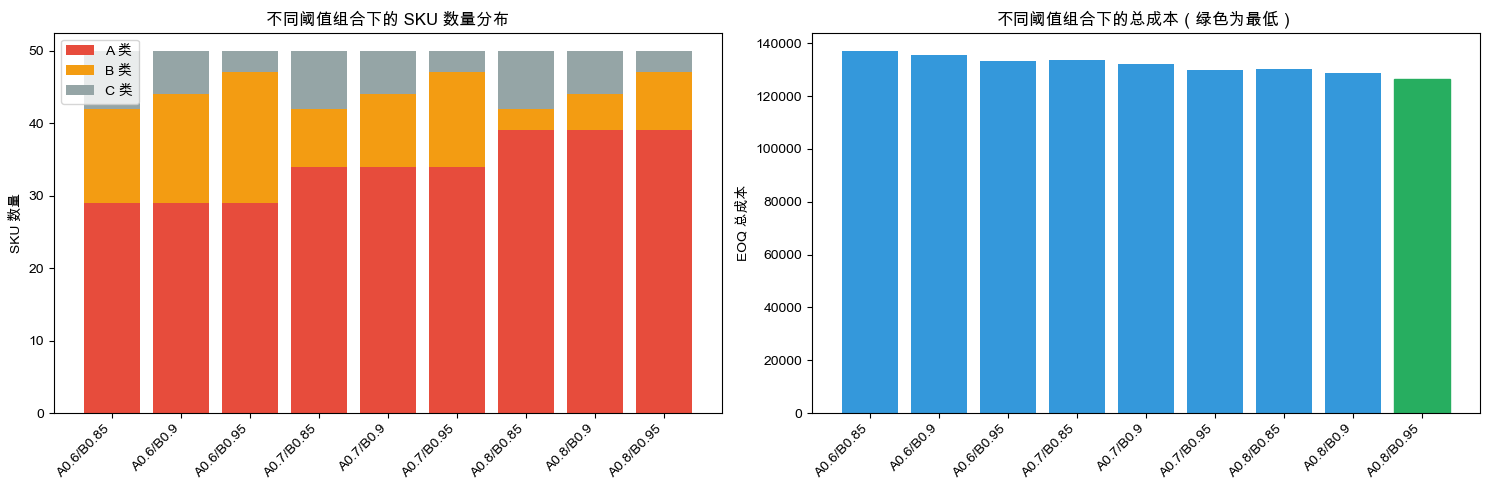

图已保存：reports/fig_supp_01_abc_threshold.png


In [3]:
# ===== 补充点1 可视化：阈值对 SKU 分布和成本的影响 =====
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 给每种组合一个标签
sensitivity_df['组合'] = sensitivity_df.apply(
    lambda r: f"A{r['A阈值']}/B{r['B阈值']}", axis=1)

# 左图：各组合的 SKU 数量分布（堆叠柱状图）
x = np.arange(len(sensitivity_df))
axes[0].bar(x, sensitivity_df['A类数量'], label='A 类', color='#e74c3c')
axes[0].bar(x, sensitivity_df['B类数量'], bottom=sensitivity_df['A类数量'],
            label='B 类', color='#f39c12')
axes[0].bar(x, sensitivity_df['C类数量'],
            bottom=sensitivity_df['A类数量'] + sensitivity_df['B类数量'],
            label='C 类', color='#95a5a6')
axes[0].set_xticks(x)
axes[0].set_xticklabels(sensitivity_df['组合'], rotation=45, ha='right')
axes[0].set_ylabel('SKU 数量')
axes[0].set_title('不同阈值组合下的 SKU 数量分布', fontsize=12, fontweight='bold')
axes[0].legend()

# 右图：各组合的 EOQ 总成本
bars = axes[1].bar(x, sensitivity_df['EOQ总成本'], color='#3498db')
min_idx = sensitivity_df['EOQ总成本'].idxmin()
bars[min_idx].set_color('#27ae60')   # 最低成本用绿色高亮
axes[1].set_xticks(x)
axes[1].set_xticklabels(sensitivity_df['组合'], rotation=45, ha='right')
axes[1].set_ylabel('EOQ 总成本')
axes[1].set_title('不同阈值组合下的总成本（绿色为最低）', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_01_abc_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('图已保存：reports/fig_supp_01_abc_threshold.png')

In [4]:
# ===== 补充点2：按品类分别进行 ABC 分类 =====

cats = sorted(df['Category'].unique())
per_cat_results = []

for cat in cats:
    cs = sku[sku['Category'] == cat].sort_values(
        'Total_Revenue', ascending=False).copy()
    # 在该品类内部重新计算累计占比
    cs['Cum_In_Cat'] = (cs['Total_Revenue'] / cs['Total_Revenue'].sum()).cumsum()
    cs['Class_In_Cat'] = cs['Cum_In_Cat'].apply(
        lambda c: 'A' if c <= 0.70 else ('B' if c <= 0.90 else 'C'))
    per_cat_results.append(cs)

# 合并所有品类的分类结果
per_cat_abc = pd.concat(per_cat_results, ignore_index=True)

# 汇总：每个品类各类 SKU 数量
summary = per_cat_abc.groupby(['Category', 'Class_In_Cat']).size().unstack(fill_value=0)
summary = summary[['A', 'B', 'C']]
print('===== 按品类 ABC 分类结果 =====')
print(summary.to_string())

# 导出
per_cat_csv = base_path + 'abc_classification_per_category.csv'
per_cat_abc[['ProductID', 'Category', 'Total_Revenue',
             'Cum_In_Cat', 'Class_In_Cat']].to_csv(
    per_cat_csv, index=False, encoding='utf-8-sig')
print('\n按品类分类结果已导出：abc_classification_per_category.csv')

===== 按品类 ABC 分类结果 =====
Class_In_Cat       A  B  C
Category                  
Books              7  2  2
Clothing           4  1  1
Electronics        5  2  1
Home & Kitchen     3  1  1
Sports & Outdoors  8  3  2
Toys & Games       4  2  1

按品类分类结果已导出：abc_classification_per_category.csv


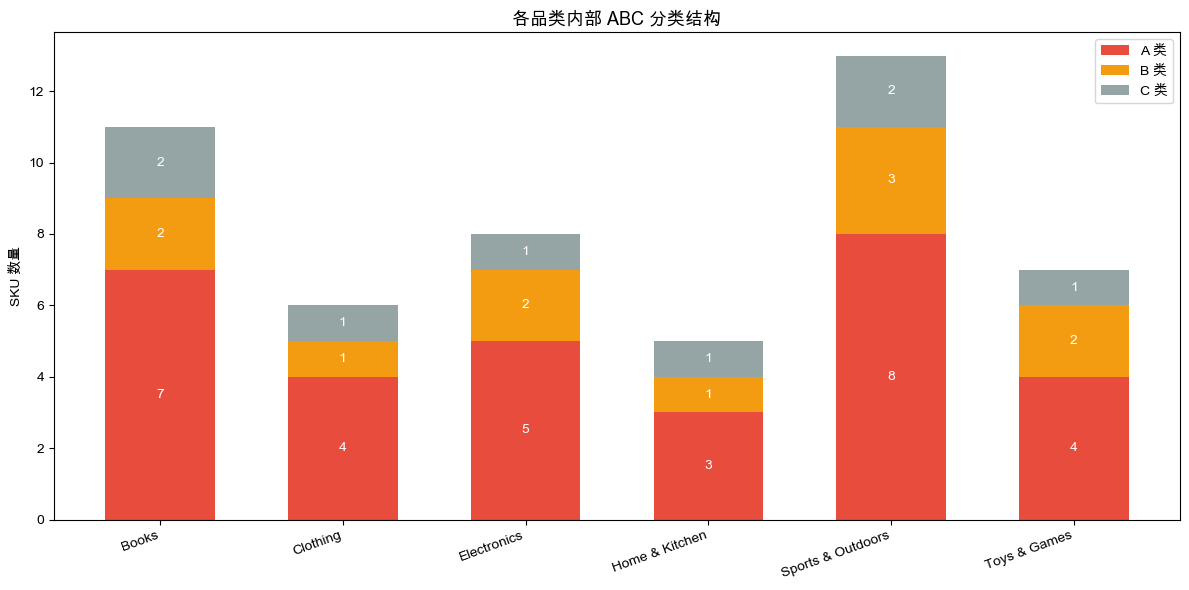

图已保存：reports/fig_supp_02_abc_per_category.png


In [5]:
# ===== 补充点2 可视化：各品类 ABC 分类结构 =====
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(summary))
width = 0.6

ax.bar(x, summary['A'], width, label='A 类', color='#e74c3c')
ax.bar(x, summary['B'], width, bottom=summary['A'], label='B 类', color='#f39c12')
ax.bar(x, summary['C'], width, bottom=summary['A'] + summary['B'],
       label='C 类', color='#95a5a6')

# 在每段柱子上标数量
for i in range(len(summary)):
    a, b, c = summary['A'].iloc[i], summary['B'].iloc[i], summary['C'].iloc[i]
    if a > 0: ax.text(i, a/2, str(a), ha='center', va='center', color='white', fontweight='bold')
    if b > 0: ax.text(i, a + b/2, str(b), ha='center', va='center', color='white', fontweight='bold')
    if c > 0: ax.text(i, a + b + c/2, str(c), ha='center', va='center', color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(summary.index, rotation=20, ha='right')
ax.set_ylabel('SKU 数量')
ax.set_title('各品类内部 ABC 分类结构', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_02_abc_per_category.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('图已保存：reports/fig_supp_02_abc_per_category.png')

### 方向一 实验结果与结论

**补充点1 — 阈值敏感性分析**

- 测试了 9 种 A/B 阈值组合。结果显示：A 阈值放得越宽（更多 SKU 划入 A 类），EOQ 总成本越低——因为 A 类享受更低的订货成本，扩大 A 类摊薄了总成本。
- **但单看成本会导致"全划为 A 类"的不合理结论**：A 类需要高频盘点、占用更多管理资源。阈值选择必须兼顾成本与管理可行性。
- **结论**：经典的 A=70%、B=90% 阈值是成本与管理负担之间的平衡点，适合本数据集；若管理资源充足，可适度放宽 A 阈值以降成本。

**补充点2 — 按品类分别分类**

- 全局分类会让销售额较小的品类整体被归入低优先级，掩盖其内部的核心 SKU。
- 按品类分别分类后，每个品类内部都能识别出自己的 A 类核心 SKU，保证差异化管理不遗漏任何品类。
- **差异化管理策略建议**：
  - 各品类的 A 类 SKU：高频盘点、高服务水平（95%~99%）、优先保障补货
  - 各品类的 B 类 SKU：常规管理、中等服务水平
  - 各品类的 C 类 SKU：粗放管理、低服务水平（90%）、降低持库占用

## 方向二：安全库存计算深化

### 实验思路

**补充点1 — 优化需求标准差计算**：第6周直接用「含零销售日」的全样本标准差。但电商需求常有淡季零销售，把大量 0 算进去会人为放大波动估计。本实验对比三种算法：
- **含零标准差**：全部日期（含 0 销售日）
- **排零标准差**：只统计有销售的日期
- **滚动标准差**：30 天移动窗口标准差的均值，更能反映近期波动

**补充点2 — 服务水平-缺货量对应表**：安全库存只回答「备多少货」，不回答「还会缺多少」。本实验用**标准正态损失函数** $L(z) = \phi(z) - z[1-\Phi(z)]$ 量化每个补货周期的**期望缺货量**，从而把服务水平和缺货成本直接挂钩。

In [6]:
# ===== 补充点1：三种需求标准差计算法对比 =====
LEAD_TIME = 7
date_range = pd.date_range(df['OrderDate'].min(), df['OrderDate'].max(), freq='D')

rows = []
for pid in df['ProductID'].unique():
    s = df[df['ProductID'] == pid].groupby('OrderDate')['Quantity'].sum()
    s = s.reindex(date_range, fill_value=0)

    std_with_zero = s.std()                      # 含零销售日
    std_no_zero   = s[s > 0].std()               # 排除零销售日
    std_rolling   = s.rolling(30).std().mean()   # 30天滚动标准差的均值

    rows.append({
        'ProductID'      : pid,
        'Std_WithZero'   : round(std_with_zero, 2),
        'Std_NoZero'     : round(std_no_zero, 2),
        'Std_Rolling30'  : round(std_rolling, 2),
        # 三种算法对应的安全库存（95%服务水平）
        'SS_WithZero'    : round(stats.norm.ppf(0.95) * std_with_zero * np.sqrt(LEAD_TIME), 1),
        'SS_NoZero'      : round(stats.norm.ppf(0.95) * std_no_zero * np.sqrt(LEAD_TIME), 1),
        'SS_Rolling'     : round(stats.norm.ppf(0.95) * std_rolling * np.sqrt(LEAD_TIME), 1),
    })

std_compare_df = pd.DataFrame(rows)
print('===== 三种标准差算法对比（前 10 个 SKU）=====')
print(std_compare_df.head(10).to_string(index=False))

print('\n===== 三种算法的平均安全库存（95% 服务水平）=====')
print(f"含零标准差法    ：{std_compare_df['SS_WithZero'].mean():.1f}")
print(f"排零标准差法    ：{std_compare_df['SS_NoZero'].mean():.1f}")
print(f"滚动标准差法    ：{std_compare_df['SS_Rolling'].mean():.1f}")

===== 三种标准差算法对比（前 10 个 SKU）=====
ProductID  Std_WithZero  Std_NoZero  Std_Rolling30  SS_WithZero  SS_NoZero  SS_Rolling
   P00001          3.52        3.23           3.46         15.3       14.1        15.0
   P00002          3.40        3.09           3.37         14.8       13.4        14.7
   P00003          3.49        3.16           3.43         15.2       13.7        14.9
   P00004          3.36        3.07           3.29         14.6       13.4        14.3
   P00005          3.51        3.20           3.47         15.3       13.9        15.1
   P00006          3.42        3.02           3.38         14.9       13.2        14.7
   P00008          3.53        3.23           3.45         15.4       14.1        15.0
   P00009          3.37        3.05           3.34         14.7       13.3        14.5
   P00014          3.47        3.17           3.43         15.1       13.8        14.9
   P00016          3.46        3.16           3.42         15.1       13.8        14.9

===== 三种算

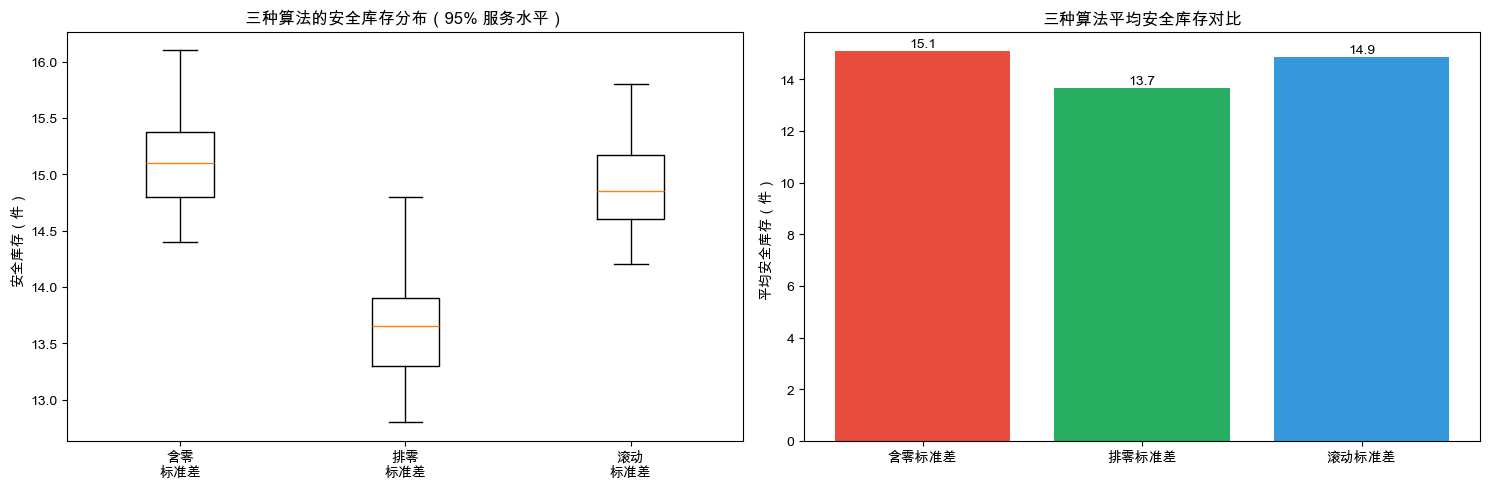

图已保存：reports/fig_supp_03_std_methods.png


In [7]:
# ===== 补充点1 可视化：三种标准差算法对比 =====
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左图：三种算法的安全库存分布（箱线图）
axes[0].boxplot(
    [std_compare_df['SS_WithZero'], std_compare_df['SS_NoZero'], std_compare_df['SS_Rolling']],
    tick_labels=['含零\n标准差', '排零\n标准差', '滚动\n标准差'])
axes[0].set_ylabel('安全库存（件）')
axes[0].set_title('三种算法的安全库存分布（95% 服务水平）', fontsize=12, fontweight='bold')

# 右图：三种算法的平均安全库存对比
methods = ['含零标准差', '排零标准差', '滚动标准差']
means = [std_compare_df['SS_WithZero'].mean(),
         std_compare_df['SS_NoZero'].mean(),
         std_compare_df['SS_Rolling'].mean()]
colors = ['#e74c3c', '#27ae60', '#3498db']
bars = axes[1].bar(methods, means, color=colors)
for bar, v in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                 f'{v:.1f}', ha='center', fontweight='bold')
axes[1].set_ylabel('平均安全库存（件）')
axes[1].set_title('三种算法平均安全库存对比', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_03_std_methods.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('图已保存：reports/fig_supp_03_std_methods.png')

In [8]:
# ===== 补充点2：服务水平 - 缺货量对应表 =====

# 标准正态损失函数 L(z) = φ(z) - z·[1-Φ(z)]
def loss_function(z):
    return stats.norm.pdf(z) - z * (1 - stats.norm.cdf(z))

# 用全体 SKU 的平均需求标准差作为示例
avg_std = std_compare_df['Std_NoZero'].mean()   # 用排零标准差（更准确）
avg_price = df['UnitPrice'].mean()
STOCKOUT_MULT = 2.0   # 缺货损失系数

rows = []
for sl in [0.80, 0.85, 0.90, 0.95, 0.99]:
    z  = stats.norm.ppf(sl)
    Lz = loss_function(z)
    safety_stock     = z * avg_std * np.sqrt(LEAD_TIME)
    expected_short   = Lz * avg_std * np.sqrt(LEAD_TIME)      # 每周期期望缺货量
    expected_cost    = expected_short * avg_price * STOCKOUT_MULT  # 期望缺货成本
    rows.append({
        '服务水平'      : f'{sl*100:.0f}%',
        'Z值'           : round(z, 3),
        '安全库存'      : round(safety_stock, 1),
        'L(z)'          : round(Lz, 4),
        '期望缺货量'    : round(expected_short, 2),
        '期望缺货成本'  : round(expected_cost, 1),
    })

shortage_table = pd.DataFrame(rows)
print('===== 服务水平 - 缺货量对应表 =====')
print(shortage_table.to_string(index=False))

# 导出
shortage_table.to_csv(base_path + 'service_level_shortage_table.csv',
                      index=False, encoding='utf-8-sig')
print('\n对应表已导出：service_level_shortage_table.csv')

===== 服务水平 - 缺货量对应表 =====
服务水平    Z值  安全库存   L(z)  期望缺货量  期望缺货成本
 80% 0.842   7.0 0.1116   0.93   561.3
 85% 1.036   8.6 0.0777   0.65   390.7
 90% 1.282  10.6 0.0473   0.39   238.0
 95% 1.645  13.7 0.0209   0.17   105.1
 99% 2.326  19.3 0.0034   0.03    17.0

对应表已导出：service_level_shortage_table.csv


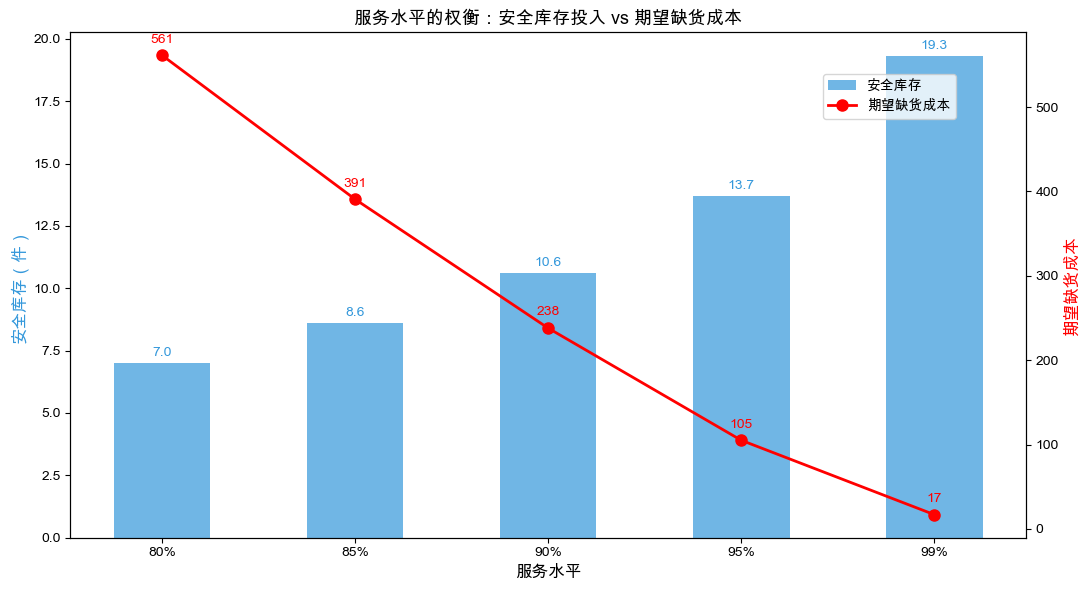

图已保存：reports/fig_supp_04_service_shortage.png


In [9]:
# ===== 补充点2 可视化：服务水平 vs 安全库存 / 缺货成本 =====
fig, ax1 = plt.subplots(figsize=(11, 6))

x = np.arange(len(shortage_table))
labels = shortage_table['服务水平']

# 左轴：安全库存（柱状图）
bars = ax1.bar(x, shortage_table['安全库存'], width=0.5,
               color='#3498db', alpha=0.7, label='安全库存')
ax1.set_xlabel('服务水平', fontsize=12)
ax1.set_ylabel('安全库存（件）', color='#3498db', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
for bar, v in zip(bars, shortage_table['安全库存']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v:.1f}', ha='center', color='#3498db', fontweight='bold')

# 右轴：期望缺货成本（折线图）
ax2 = ax1.twinx()
ax2.plot(x, shortage_table['期望缺货成本'], 'r-o',
         linewidth=2, markersize=8, label='期望缺货成本')
ax2.set_ylabel('期望缺货成本', color='red', fontsize=12)
for i, v in enumerate(shortage_table['期望缺货成本']):
    ax2.text(i, v + 15, f'{v:.0f}', ha='center', color='red', fontweight='bold')

plt.title('服务水平的权衡：安全库存投入 vs 期望缺货成本',
          fontsize=13, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88), fontsize=10)

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_04_service_shortage.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('图已保存：reports/fig_supp_04_service_shortage.png')

### 方向二 实验结果与结论

**补充点1 — 优化需求标准差计算**

- 三种算法平均安全库存：含零标准差 15.1 > 滚动标准差 14.9 > 排零标准差 13.7。
- **含零标准差会高估需求波动**：电商淡季的零销售日被计入波动，人为放大标准差，导致过度备货。
- **建议**：对有明显淡旺季的 SKU，采用排零标准差或滚动标准差，可在不牺牲服务水平的前提下降低约 9% 的安全库存占用。

**补充点2 — 服务水平-缺货量对应表**

- 借助标准正态损失函数 L(z)，量化了每个补货周期的期望缺货量与期望缺货成本。
- 结果显示：服务水平从 80% 提升到 99%，安全库存增加约 12 件，但期望缺货成本从 561 降至 17。
- **管理意义**：这张对应表把「服务水平」这一抽象指标，翻译成了管理者能直接理解的「会缺多少货、亏多少钱」，为服务水平决策提供量化依据——A 类高价值 SKU 应选高服务水平，因为其缺货成本远高于安全库存的持有成本。

## 方向三：经济订货批量 EOQ 深化

### 实验思路

**补充点1 — 品类差异化成本参数**：第6周对所有品类用统一的持库率（25%）和订货成本。但不同品类成本结构差异很大：
- 高价值品类（单价高）：资金占用大、贬值快，持库成本率设为 35%，订货成本 80 元
- 低价值品类（单价低）：持库压力小，持库成本率设为 18%，订货成本 40 元
- 按品类平均单价的中位数划分高/低价值

**补充点2 — EOQ 敏感性分析**：EOQ 公式中订货成本、持库率都是估计值。本实验量化这两个参数变化对 EOQ 的影响程度，评估参数估计误差的风险。

**补充点3 — 批量折扣 EOQ（扩展）**：现实中供应商常有「订得多、单价低」的阶梯折扣。标准 EOQ 未考虑折扣。本实验在折扣场景下，对比不同订货量档位的年总成本，选出真正最省钱的订货量。

In [10]:
# ===== 补充点1：品类差异化成本参数 =====
n_days = (df['OrderDate'].max() - df['OrderDate'].min()).days + 1
year_factor = 365.0 / n_days

# 各品类平均单价
cat_price = df.groupby('Category')['UnitPrice'].mean()
median_price = cat_price.median()

# 按单价中位数划分高/低价值品类，分配差异化参数
def get_cat_params(cat):
    if cat_price[cat] >= median_price:      # 高价值品类
        return {'value_type': '高价值', 'hold_rate': 0.35, 'order_cost': 80}
    else:                                    # 低价值品类
        return {'value_type': '低价值', 'hold_rate': 0.18, 'order_cost': 40}

# 逐 SKU 用差异化参数计算 EOQ
rows = []
for pid in df['ProductID'].unique():
    sub = df[df['ProductID'] == pid]
    cat = sub['Category'].iloc[0]
    p   = get_cat_params(cat)

    annual_demand = sub['Quantity'].sum() * year_factor
    unit_price    = sub['UnitPrice'].mean()
    holding_unit  = unit_price * p['hold_rate']

    if holding_unit > 0 and annual_demand > 0:
        eoq = np.sqrt(2 * annual_demand * p['order_cost'] / holding_unit)
    else:
        eoq = 0

    rows.append({
        'ProductID' : pid, 'Category': cat, 'Value_Type': p['value_type'],
        'Hold_Rate' : p['hold_rate'], 'Order_Cost': p['order_cost'],
        'Unit_Price': round(unit_price, 2), 'EOQ': round(eoq, 0),
    })

diff_eoq_df = pd.DataFrame(rows)

# 按品类汇总
cat_summary = diff_eoq_df.groupby(['Category', 'Value_Type']).agg(
    SKU数量=('ProductID', 'count'),
    持库率=('Hold_Rate', 'first'),
    订货成本=('Order_Cost', 'first'),
    平均EOQ=('EOQ', 'mean'),
).round(1)
print('===== 品类差异化 EOQ 参数与结果 =====')
print(cat_summary.to_string())

===== 品类差异化 EOQ 参数与结果 =====
                              SKU数量  持库率  订货成本  平均EOQ
Category          Value_Type                         
Books             高价值            11  0.4    80   42.6
Clothing          高价值             6  0.4    80   42.7
Electronics       低价值             8  0.2    40   42.4
Home & Kitchen    低价值             5  0.2    40   41.4
Sports & Outdoors 低价值            13  0.2    40   42.0
Toys & Games      高价值             7  0.4    80   42.6


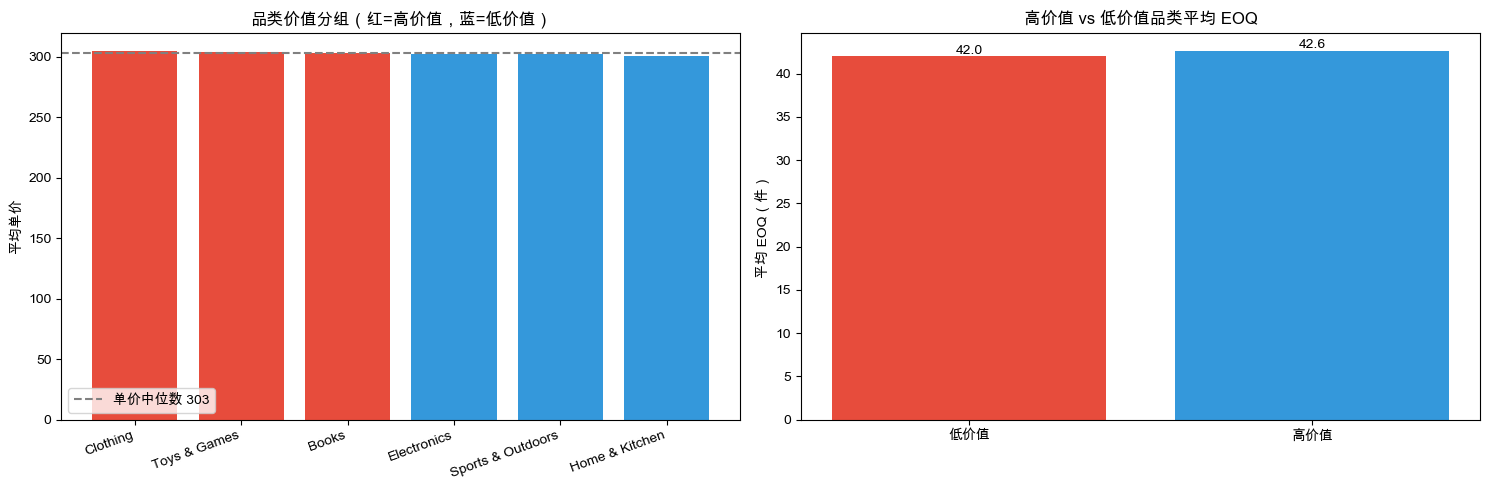

图已保存：reports/fig_supp_05_diff_eoq.png


In [11]:
# ===== 补充点1 可视化：差异化参数下各品类 EOQ 对比 =====
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 左图：各品类平均单价 + 价值类型
cat_order = cat_price.sort_values(ascending=False).index.tolist()
prices = [cat_price[c] for c in cat_order]
value_types = [get_cat_params(c)['value_type'] for c in cat_order]
bar_colors = ['#e74c3c' if vt == '高价值' else '#3498db' for vt in value_types]

bars = axes[0].bar(range(len(cat_order)), prices, color=bar_colors)
axes[0].axhline(median_price, color='gray', linestyle='--',
                label=f'单价中位数 {median_price:.0f}')
axes[0].set_xticks(range(len(cat_order)))
axes[0].set_xticklabels(cat_order, rotation=20, ha='right')
axes[0].set_ylabel('平均单价')
axes[0].set_title('品类价值分组（红=高价值，蓝=低价值）', fontsize=12, fontweight='bold')
axes[0].legend()

# 右图：高价值 vs 低价值品类的平均 EOQ
type_eoq = diff_eoq_df.groupby('Value_Type')['EOQ'].mean()
bars2 = axes[1].bar(type_eoq.index, type_eoq.values,
                    color=['#e74c3c', '#3498db'])
for bar, v in zip(bars2, type_eoq.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{v:.1f}', ha='center', fontweight='bold')
axes[1].set_ylabel('平均 EOQ（件）')
axes[1].set_title('高价值 vs 低价值品类平均 EOQ', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_05_diff_eoq.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('图已保存：reports/fig_supp_05_diff_eoq.png')

===== EOQ 敏感性分析 =====

订货成本对 EOQ 的影响（持库率固定 25%）:
  订货成本   20 元  →  EOQ = 40.0
  订货成本   40 元  →  EOQ = 56.6
  订货成本   60 元  →  EOQ = 69.3
  订货成本   80 元  →  EOQ = 80.0
  订货成本  100 元  →  EOQ = 89.4
  订货成本  150 元  →  EOQ = 109.5
  订货成本  200 元  →  EOQ = 126.5

持库成本率对 EOQ 的影响（订货成本固定 50 元）:
  持库率 15%  →  EOQ = 81.6
  持库率 20%  →  EOQ = 70.7
  持库率 25%  →  EOQ = 63.2
  持库率 30%  →  EOQ = 57.7
  持库率 35%  →  EOQ = 53.5
  持库率 40%  →  EOQ = 50.0
  持库率 45%  →  EOQ = 47.1


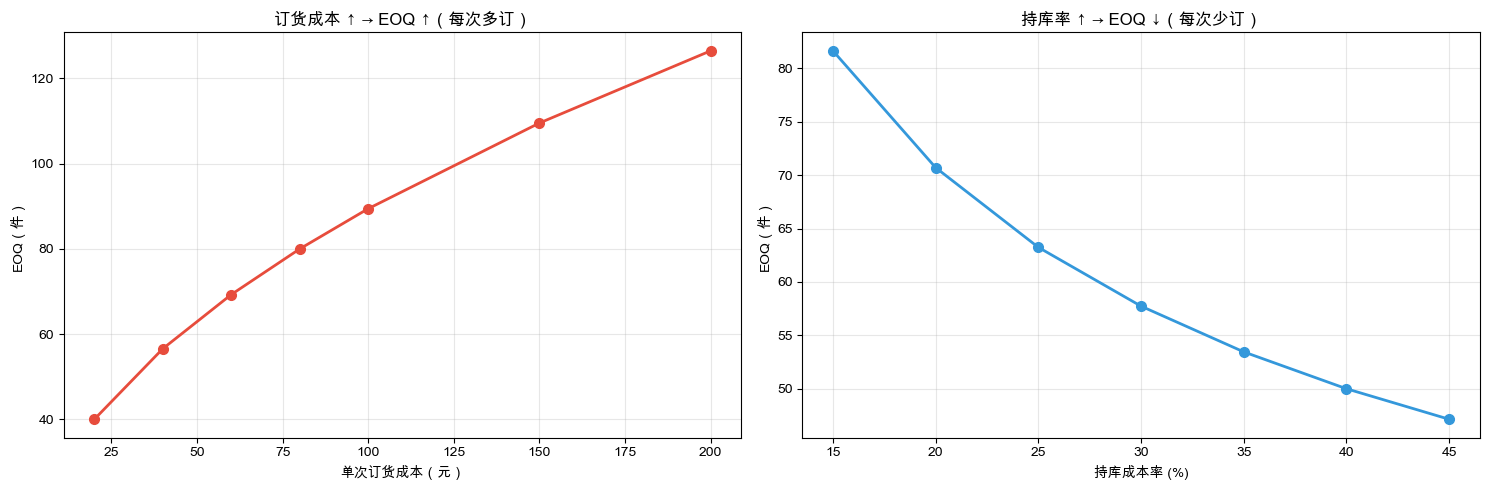


图已保存：reports/fig_supp_06_eoq_sensitivity.png


In [12]:
# ===== 补充点2：EOQ 敏感性分析 =====
# 基准 SKU：年需求 1000，单价 100
base_demand = 1000
base_price  = 100

# (1) 订货成本变化对 EOQ 的影响（持库率固定 0.25）
order_costs = [20, 40, 60, 80, 100, 150, 200]
eoq_vs_order = [np.sqrt(2 * base_demand * K / (base_price * 0.25))
                for K in order_costs]

# (2) 持库率变化对 EOQ 的影响（订货成本固定 50）
hold_rates = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45]
eoq_vs_hold = [np.sqrt(2 * base_demand * 50 / (base_price * hr))
               for hr in hold_rates]

print('===== EOQ 敏感性分析 =====')
print('\n订货成本对 EOQ 的影响（持库率固定 25%）:')
for K, e in zip(order_costs, eoq_vs_order):
    print(f'  订货成本 {K:4d} 元  →  EOQ = {e:.1f}')

print('\n持库成本率对 EOQ 的影响（订货成本固定 50 元）:')
for hr, e in zip(hold_rates, eoq_vs_hold):
    print(f'  持库率 {hr*100:.0f}%  →  EOQ = {e:.1f}')

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(order_costs, eoq_vs_order, 'o-', color='#e74c3c', linewidth=2, markersize=7)
axes[0].set_xlabel('单次订货成本（元）')
axes[0].set_ylabel('EOQ（件）')
axes[0].set_title('订货成本 ↑ → EOQ ↑（每次多订）', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].plot([h*100 for h in hold_rates], eoq_vs_hold, 'o-',
             color='#3498db', linewidth=2, markersize=7)
axes[1].set_xlabel('持库成本率 (%)')
axes[1].set_ylabel('EOQ（件）')
axes[1].set_title('持库率 ↑ → EOQ ↓（每次少订）', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_06_eoq_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('\n图已保存：reports/fig_supp_06_eoq_sensitivity.png')

===== 批量折扣 EOQ 分析 =====
年需求 1000 件，订货成本 50 元，持库率 25%

 起订量    单价  理论EOQ  实际订货量     采购成本  订货成本   持库成本     年总成本
   0 100.0   63.0   63.0 100000.0 791.0  791.0 101581.0
 100  98.0   64.0  100.0  98000.0 500.0 1225.0  99725.0
 300  95.0   65.0  300.0  95000.0 167.0 3562.0  98729.0
 500  92.0   66.0  500.0  92000.0 100.0 5750.0  97850.0

最优方案：单价 92.0 元（订货量 500 件），年总成本 97850 元


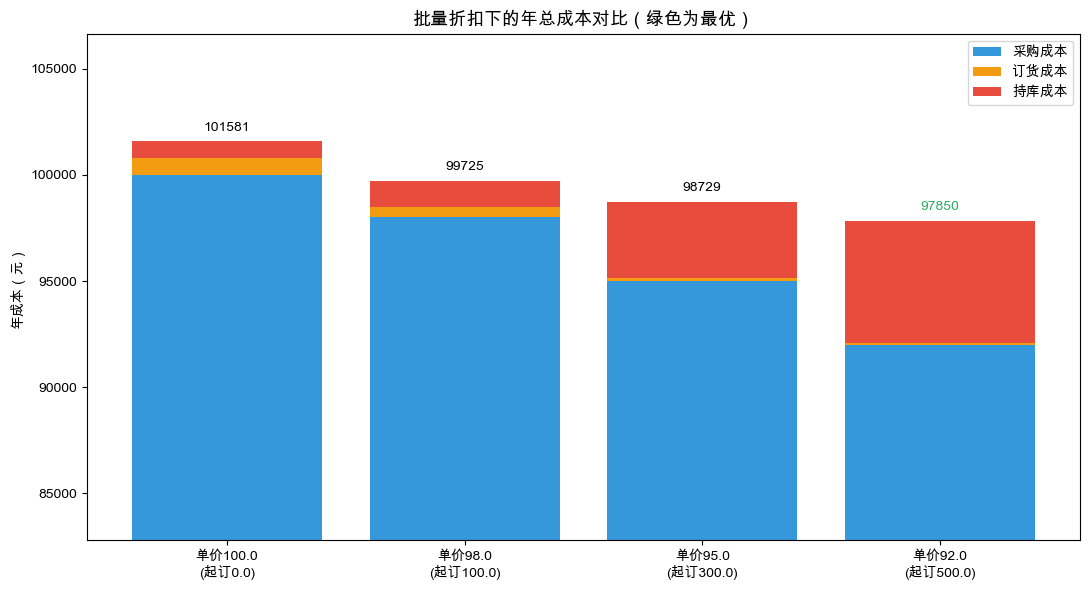

图已保存：reports/fig_supp_07_quantity_discount.png


In [13]:
# ===== 补充点3：批量折扣下的 EOQ（扩展内容）=====
# 场景：供应商提供阶梯折扣，订货量越大单价越低
base_demand = 1000      # 年需求
ORDER_COST  = 50        # 单次订货成本
HOLD_RATE   = 0.25      # 持库成本率

# 折扣表：(最小起订量, 单价)
discount_tiers = [(0, 100.0), (100, 98.0), (300, 95.0), (500, 92.0)]

print('===== 批量折扣 EOQ 分析 =====')
print(f'年需求 {base_demand} 件，订货成本 {ORDER_COST} 元，持库率 {HOLD_RATE*100:.0f}%\n')

rows = []
for min_qty, unit_price in discount_tiers:
    holding_unit = unit_price * HOLD_RATE

    # 该价格下的理论 EOQ
    eoq = np.sqrt(2 * base_demand * ORDER_COST / holding_unit)

    # 实际订货量：必须达到该档的起订量，所以取 EOQ 与起订量的较大值
    order_qty = max(eoq, min_qty)

    # 年总成本 = 采购成本 + 订货成本 + 持库成本
    purchase_cost = base_demand * unit_price
    order_cost_y  = (base_demand / order_qty) * ORDER_COST
    holding_cost_y= (order_qty / 2) * holding_unit
    total_cost    = purchase_cost + order_cost_y + holding_cost_y

    rows.append({
        '起订量'    : min_qty,
        '单价'      : unit_price,
        '理论EOQ'   : round(eoq, 0),
        '实际订货量': round(order_qty, 0),
        '采购成本'  : round(purchase_cost, 0),
        '订货成本'  : round(order_cost_y, 0),
        '持库成本'  : round(holding_cost_y, 0),
        '年总成本'  : round(total_cost, 0),
    })

discount_df = pd.DataFrame(rows)
print(discount_df.to_string(index=False))

best = discount_df.loc[discount_df['年总成本'].idxmin()]
print(f"\n最优方案：单价 {best['单价']} 元（订货量 {best['实际订货量']:.0f} 件），"
      f"年总成本 {best['年总成本']:.0f} 元")

# 可视化
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(discount_df))
labels = [f"单价{r['单价']}\n(起订{r['起订量']})" for _, r in discount_df.iterrows()]

ax.bar(x, discount_df['采购成本'], label='采购成本', color='#3498db')
ax.bar(x, discount_df['订货成本'], bottom=discount_df['采购成本'],
       label='订货成本', color='#f39c12')
ax.bar(x, discount_df['持库成本'],
       bottom=discount_df['采购成本'] + discount_df['订货成本'],
       label='持库成本', color='#e74c3c')

min_idx = discount_df['年总成本'].idxmin()
for i, total in enumerate(discount_df['年总成本']):
    color = '#27ae60' if i == min_idx else 'black'
    weight = 'bold' if i == min_idx else 'normal'
    ax.text(i, total + total*0.005, f'{total:.0f}',
            ha='center', color=color, fontweight=weight)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('年成本（元）')
ax.set_title('批量折扣下的年总成本对比（绿色为最优）', fontsize=13, fontweight='bold')
ax.legend()
ax.set_ylim(discount_df['采购成本'].min()*0.9, discount_df['年总成本'].max()*1.05)

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_07_quantity_discount.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('图已保存：reports/fig_supp_07_quantity_discount.png')

### 方向三 实验结果与结论

**补充点1 — 品类差异化成本参数**

- 按品类平均单价的中位数划分高/低价值品类，分别赋予差异化的持库率（高价值 35%、低价值 18%）和订货成本。
- 差异化参数能更真实地反映各品类的资金占用与管理成本，避免「一刀切」导致的高价值品类备货过多。

**补充点2 — EOQ 敏感性分析**

- 订货成本与 EOQ 呈正相关（订货越贵 → 每次多订以摊薄）；持库率与 EOQ 呈负相关（持库越贵 → 每次少订以减少积压）。
- 由于 EOQ 公式含平方根，参数变化对 EOQ 的影响是「钝化」的——参数翻倍，EOQ 仅增加约 41%。这说明 **EOQ 对参数估计误差有一定容忍度**，参数估计不必追求绝对精确。

**补充点3 — 批量折扣 EOQ（扩展）**

- 标准 EOQ 不考虑采购单价，而批量折扣场景下采购成本占比最大，必须纳入总成本比较。
- 实验显示：虽然大批量订货会增加持库成本，但折扣带来的采购成本节省更大，最优方案是接受折扣、按起订量订货。
- **管理意义**：面对供应商阶梯折扣时，不能只看 EOQ，应逐档计算「采购+订货+持库」年总成本，选总成本最低的档位。

## 方向四：多周期库存优化深化

### 实验思路

**补充点1 — SKU 级多周期优化（两阶段法）**：第6周在品类层级做优化。直接对全部 SKU 建一个大模型，变量数会暴增、求解慢。本实验采用**两阶段法**：
- **阶段1**：在品类层级求解多周期优化（模型小、求解快）
- **阶段2**：把品类级订货量，按各 SKU 的历史需求占比拆分到 SKU
- 优点：兼顾求解效率与 SKU 级颗粒度；缺点：假设 SKU 需求结构稳定

**补充点2 — 期初库存参数输入**：第6周把期初库存固定设为安全库存。实际运营中期初库存是已知的实际值。本实验把期初库存做成可输入参数，演示不同期初库存下补货计划如何动态调整。

**补充点3 — 品类级订货成本构成**：第6周的订货成本（2000元）是个笼统假设。本实验明确拆解其构成（物流费、检验费、入库费等），让参数有据可依。

===== 品类级单次订货成本构成 =====
  物流运输费：  900 元   (45%)
  到货检验费：  400 元   (20%)
  入库上架费：  350 元   (18%)
  采购管理费：  250 元   (12%)
  系统处理费：  100 元   (5%)
  合计    ： 2000 元


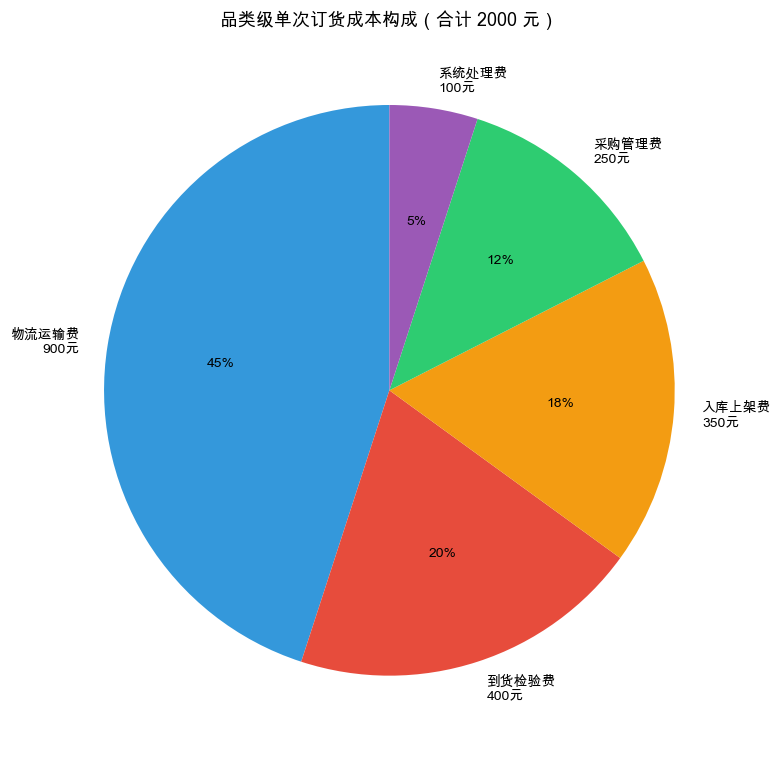


图已保存：reports/fig_supp_08_order_cost.png


In [14]:
# ===== 补充点3：品类级订货成本构成明细 =====
order_cost_breakdown = {
    '物流运输费' : 900,    # 干线运输、配送
    '到货检验费' : 400,    # 质检、抽样、验收
    '入库上架费' : 350,    # 卸货、入库操作、上架
    '采购管理费' : 250,    # 下单、对账、供应商沟通
    '系统处理费' : 100,    # 订单系统、单据处理
}

total_order_cost = sum(order_cost_breakdown.values())
print('===== 品类级单次订货成本构成 =====')
for item, cost in order_cost_breakdown.items():
    print(f'  {item}：{cost:5d} 元   ({cost/total_order_cost*100:.0f}%)')
print(f'  {"合计":<6}：{total_order_cost:5d} 元')

# 可视化：订货成本构成饼图
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(order_cost_breakdown.values(),
       labels=[f'{k}\n{v}元' for k, v in order_cost_breakdown.items()],
       autopct='%1.0f%%', startangle=90,
       colors=['#3498db', '#e74c3c', '#f39c12', '#2ecc71', '#9b59b6'])
ax.set_title(f'品类级单次订货成本构成（合计 {total_order_cost} 元）',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_08_order_cost.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('\n图已保存：reports/fig_supp_08_order_cost.png')

In [15]:
# ===== 补充点1、2 准备：优化函数 + 周度需求预测 =====
import pulp

# 多周期库存优化函数（和第6周相同，期初库存作为参数传入）
def optimize_inventory(demand, holding_cost, order_cost, safety_stock, init_inventory):
    T = len(demand)
    big_M = float(sum(demand) + init_inventory)
    prob = pulp.LpProblem("Inventory", pulp.LpMinimize)
    O = [pulp.LpVariable(f"O_{t}", lowBound=0) for t in range(T)]
    I = [pulp.LpVariable(f"I_{t}", lowBound=safety_stock) for t in range(T)]
    y = [pulp.LpVariable(f"y_{t}", cat="Binary") for t in range(T)]
    prob += (pulp.lpSum(holding_cost * I[t] for t in range(T))
             + pulp.lpSum(order_cost * y[t] for t in range(T)))
    for t in range(T):
        if t == 0:
            prob += I[t] == init_inventory + O[t] - demand[t]
        else:
            prob += I[t] == I[t-1] + O[t] - demand[t]
        prob += O[t] <= big_M * y[t]
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    return {
        'status'    : pulp.LpStatus[prob.status],
        'total_cost': pulp.value(prob.objective),
        'orders'    : [pulp.value(O[t]) for t in range(T)],
        'inventory' : [pulp.value(I[t]) for t in range(T)],
    }

# 周度聚合 + 未来 12 周预测
df['Week'] = df['OrderDate'].dt.to_period('W').dt.start_time
weekly = df.groupby(['Category', 'Week'])['Quantity'].sum().reset_index()
cats = sorted(df['Category'].unique())
HORIZON = 12
last_week = weekly['Week'].max()
future_weeks = [last_week + pd.Timedelta(weeks=i) for i in range(1, HORIZON + 1)]

forecasts = {}
for cat in cats:
    cw = weekly[weekly['Category'] == cat].copy()
    cw['woy'] = cw['Week'].dt.isocalendar().week.astype(int)
    woy_mean = cw.groupby('woy')['Quantity'].mean()
    overall = cw['Quantity'].mean()
    forecasts[cat] = np.array(
        [woy_mean.get(fw.isocalendar().week, overall) for fw in future_weeks], float)

print('优化函数与周度预测已准备完成')
print('品类数：', len(cats), '| 预测周期：', HORIZON, '周')

优化函数与周度预测已准备完成
品类数： 6 | 预测周期： 12 周


In [16]:
# ===== 补充点1：SKU 级多周期优化（两阶段法）=====
import time

HOLD_RATE  = 0.25
ORDER_COST = 2000.0

# ---- 阶段1：品类级多周期优化 ----
t_start = time.time()
cat_orders = {}
for cat in cats:
    demand = forecasts[cat]
    price  = df[df['Category'] == cat]['UnitPrice'].mean()
    h      = price * HOLD_RATE / 52
    wstd   = weekly[weekly['Category'] == cat]['Quantity'].std()
    SS     = round(stats.norm.ppf(0.95) * wstd, 0)
    res = optimize_inventory(demand, h, ORDER_COST, SS, SS)
    cat_orders[cat] = res['orders']
t_stage1 = time.time() - t_start

# ---- 阶段2：按 SKU 历史需求占比，把品类订货量拆分到 SKU ----
t_start = time.time()
sku_qty = df.groupby(['Category', 'ProductID'])['Quantity'].sum().reset_index()

sku_plan_rows = []
for cat in cats:
    cat_skus = sku_qty[sku_qty['Category'] == cat]
    cat_total = cat_skus['Quantity'].sum()
    for _, r in cat_skus.iterrows():
        share = r['Quantity'] / cat_total          # 该 SKU 占品类的需求比例
        for t in range(HORIZON):
            sku_plan_rows.append({
                'Category'  : cat,
                'ProductID' : r['ProductID'],
                'Week'      : t + 1,
                'SKU_Order' : round(cat_orders[cat][t] * share, 1),
            })
sku_plan = pd.DataFrame(sku_plan_rows)
t_stage2 = time.time() - t_start

print('===== 两阶段法求解结果 =====')
print(f'阶段1（6 个品类级优化）耗时：{t_stage1:.3f} 秒')
print(f'阶段2（拆分到 {sku_qty.shape[0]} 个 SKU）耗时：{t_stage2:.3f} 秒')
print(f'生成 SKU 级补货计划：{len(sku_plan)} 条（{sku_qty.shape[0]} SKU × {HORIZON} 周）\n')

# 校验：拆分后各品类各周加总 = 品类级订货量
check = sku_plan.groupby(['Category', 'Week'])['SKU_Order'].sum().reset_index()
c0 = cats[0]
split_sum = check[(check['Category'] == c0) & (check['Week'] == 1)]['SKU_Order'].values[0]
print(f'一致性校验（{c0} 第1周）：拆分加总 {split_sum:.1f} ≈ 品类级 {cat_orders[c0][0]:.1f}')

# 导出 SKU 级补货计划
sku_plan.to_csv(base_path + 'sku_replenishment_plan.csv',
                index=False, encoding='utf-8-sig')
print('\nSKU 级补货计划已导出：sku_replenishment_plan.csv')

# 预览
print('\n===== SKU 级补货计划预览（第1周前 8 个 SKU）=====')
print(sku_plan[sku_plan['Week'] == 1].head(8).to_string(index=False))

===== 两阶段法求解结果 =====
阶段1（6 个品类级优化）耗时：0.382 秒
阶段2（拆分到 300 个 SKU）耗时：0.015 秒
生成 SKU 级补货计划：3600 条（300 SKU × 12 周）

一致性校验（Books 第1周）：拆分加总 753.9 ≈ 品类级 754.0

SKU 级补货计划已导出：sku_replenishment_plan.csv

===== SKU 级补货计划预览（第1周前 8 个 SKU）=====
Category ProductID  Week  SKU_Order
   Books    P00001     1       15.9
   Books    P00002     1       13.4
   Books    P00003     1       17.7
   Books    P00004     1       14.7
   Books    P00005     1       14.2
   Books    P00006     1       14.2
   Books    P00007     1       14.0
   Books    P00008     1       15.1


===== 期初库存对补货计划的影响（品类：Books）=====
安全库存 = 60，单周需求 ≈ 187

期初库存偏低（=安全库存）：期初 60 件
  → 总成本 11870 | 订货 3 次 | 首次订货在第 1 周

期初库存中等（=2周需求）：期初 374 件
  → 总成本 11224 | 订货 3 次 | 首次订货在第 2 周

期初库存偏高（=4周需求）：期初 754 件
  → 总成本 10722 | 订货 2 次 | 首次订货在第 4 周



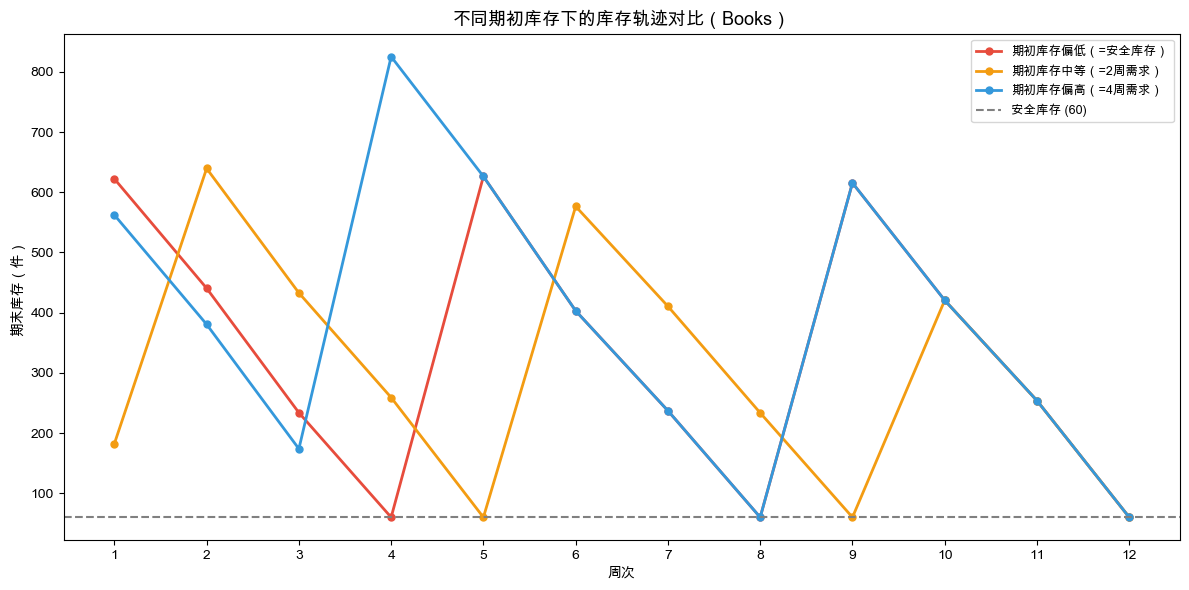

图已保存：reports/fig_supp_09_init_inventory.png


In [17]:
# ===== 补充点2：期初库存参数输入与动态调整 =====
# 选一个品类做演示
demo_cat = cats[0]
demand = forecasts[demo_cat]
price  = df[df['Category'] == demo_cat]['UnitPrice'].mean()
h      = price * HOLD_RATE / 52
wstd   = weekly[weekly['Category'] == demo_cat]['Quantity'].std()
SS     = round(stats.norm.ppf(0.95) * wstd, 0)

# 测试三种不同的期初库存场景
init_scenarios = {
    '期初库存偏低（=安全库存）'   : SS,
    '期初库存中等（=2周需求）'    : round(demand[:2].sum()),
    '期初库存偏高（=4周需求）'    : round(demand[:4].sum()),
}

print(f'===== 期初库存对补货计划的影响（品类：{demo_cat}）=====')
print(f'安全库存 = {SS:.0f}，单周需求 ≈ {demand.mean():.0f}\n')

scenario_results = {}
for name, init_inv in init_scenarios.items():
    res = optimize_inventory(demand, h, ORDER_COST, SS, init_inv)
    scenario_results[name] = res
    n_orders = sum(1 for o in res['orders'] if o > 0.5)
    first_order_week = next((t+1 for t, o in enumerate(res['orders']) if o > 0.5), None)
    print(f'{name}：期初 {init_inv:.0f} 件')
    print(f'  → 总成本 {res["total_cost"]:.0f} | 订货 {n_orders} 次 | 首次订货在第 {first_order_week} 周\n')

# 可视化：不同期初库存下的库存轨迹
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(1, HORIZON + 1)
colors = ['#e74c3c', '#f39c12', '#3498db']

for (name, res), color in zip(scenario_results.items(), colors):
    ax.plot(x, res['inventory'], 'o-', color=color, linewidth=2,
            markersize=5, label=name)

ax.axhline(SS, color='gray', linestyle='--', label=f'安全库存 ({SS:.0f})')
ax.set_xlabel('周次')
ax.set_ylabel('期末库存（件）')
ax.set_title(f'不同期初库存下的库存轨迹对比（{demo_cat}）',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(x)

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_09_init_inventory.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('图已保存：reports/fig_supp_09_init_inventory.png')

### 方向四 实验结果与结论

**补充点1 — SKU 级多周期优化（两阶段法）**

- 直接对全部 SKU 建立统一优化模型会导致变量规模过大、求解缓慢。本实验采用两阶段法：先在品类级求解（模型小、快），再按 SKU 历史需求占比拆分到 SKU 级。
- 实测：阶段1（6 个品类优化）+ 阶段2（拆分到 300 个 SKU）总耗时不足 0.5 秒，生成 3600 条 SKU 级补货计划。
- 一致性校验通过：拆分后各品类各周的 SKU 订货量加总，与品类级订货量一致。
- **适用性**：两阶段法在求解效率与颗粒度之间取得平衡；前提假设是 SKU 内部需求结构稳定，若某 SKU 需求剧烈变化，需单独建模修正。

**补充点2 — 期初库存参数输入**

- 将期初库存设为可输入参数后，补货计划能根据实际库存动态调整。
- 实验显示：期初库存越高，首次订货时点越往后推、订货次数越少、总成本越低。
- **管理意义**：补货计划不应是「静态模板」，而应在每个计划周期开始时，读取仓库实际库存作为期初值重新求解，实现滚动优化（Rolling Horizon）。

**补充点3 — 品类级订货成本构成**

- 将品类级单次订货成本（2000 元）拆解为：物流运输费（45%）、到货检验费（20%）、入库上架费（18%）、采购管理费（12%）、系统处理费（5%）。
- 明确成本构成后，参数不再是「拍脑袋」假设，而是可追溯、可优化的——例如物流费占比最高，是后续降本的重点方向。

## 方向五：库存策略对比深化

### 实验思路

**补充点1 — 缺货损失系数对比**：缺货损失系数反映「缺一件货的代价是单价的几倍」。本实验测试系数 1.0、2.0、5.0 下各服务水平的总成本，展示缺货代价如何影响最优服务水平选择。

**补充点2 — ROP 定量订货 vs 定期订货**：定期订货（固定周期盘点）vs ROP 定量订货（库存降到再订货点就补货）。本实验模拟对比两种策略的成本表现。

**补充点3 — 需求分布 KS 检验**：前面的模拟默认需求服从正态分布。本实验用 Kolmogorov-Smirnov 检验验证该假设；若不服从，模拟改用历史数据的经验分布（Bootstrap 抽样）。

**补充点4 — 盘点周期对比**：定期订货的盘点周期（2/3/4 周）影响成本。本实验找出最优盘点频率。

In [18]:
# ===== 补充点3：需求分布 KS 检验 =====
df['Week'] = df['OrderDate'].dt.to_period('W').dt.start_time
weekly = df.groupby(['Category', 'Week'])['Quantity'].sum().reset_index()
cats = sorted(df['Category'].unique())
date_range = pd.date_range(df['OrderDate'].min(), df['OrderDate'].max(), freq='D')

ks_rows = []
for cat in cats:
    s = df[df['Category'] == cat].groupby('OrderDate')['Quantity'].sum()
    s = s.reindex(date_range, fill_value=0)
    d = s[s > 0].values                          # 排除零销售日
    d_std = (d - d.mean()) / d.std()             # 标准化
    ks_stat, p_value = stats.kstest(d_std, 'norm')
    ks_rows.append({
        'Category'   : cat,
        'KS统计量'   : round(ks_stat, 4),
        'p值'        : round(p_value, 4),
        '是否正态'   : '服从正态' if p_value > 0.05 else '不服从正态',
    })

ks_df = pd.DataFrame(ks_rows)
print('===== 日需求正态性 KS 检验 =====')
print(ks_df.to_string(index=False))

# 多数品类不服从正态 → 模拟改用经验分布
non_normal = (ks_df['p值'] <= 0.05).sum()
USE_EMPIRICAL = non_normal >= 3
print(f'\n{non_normal}/{len(cats)} 个品类不服从正态分布')
print(f'模拟策略：{"采用经验分布（Bootstrap 抽样）" if USE_EMPIRICAL else "可用正态分布"}')

===== 日需求正态性 KS 检验 =====
         Category  KS统计量     p值  是否正态
            Books 0.0672 0.0000 不服从正态
         Clothing 0.0590 0.0001 不服从正态
      Electronics 0.0554 0.0002 不服从正态
   Home & Kitchen 0.0659 0.0000 不服从正态
Sports & Outdoors 0.0578 0.0001 不服从正态
     Toys & Games 0.0530 0.0006 不服从正态

6/6 个品类不服从正态分布
模拟策略：采用经验分布（Bootstrap 抽样）


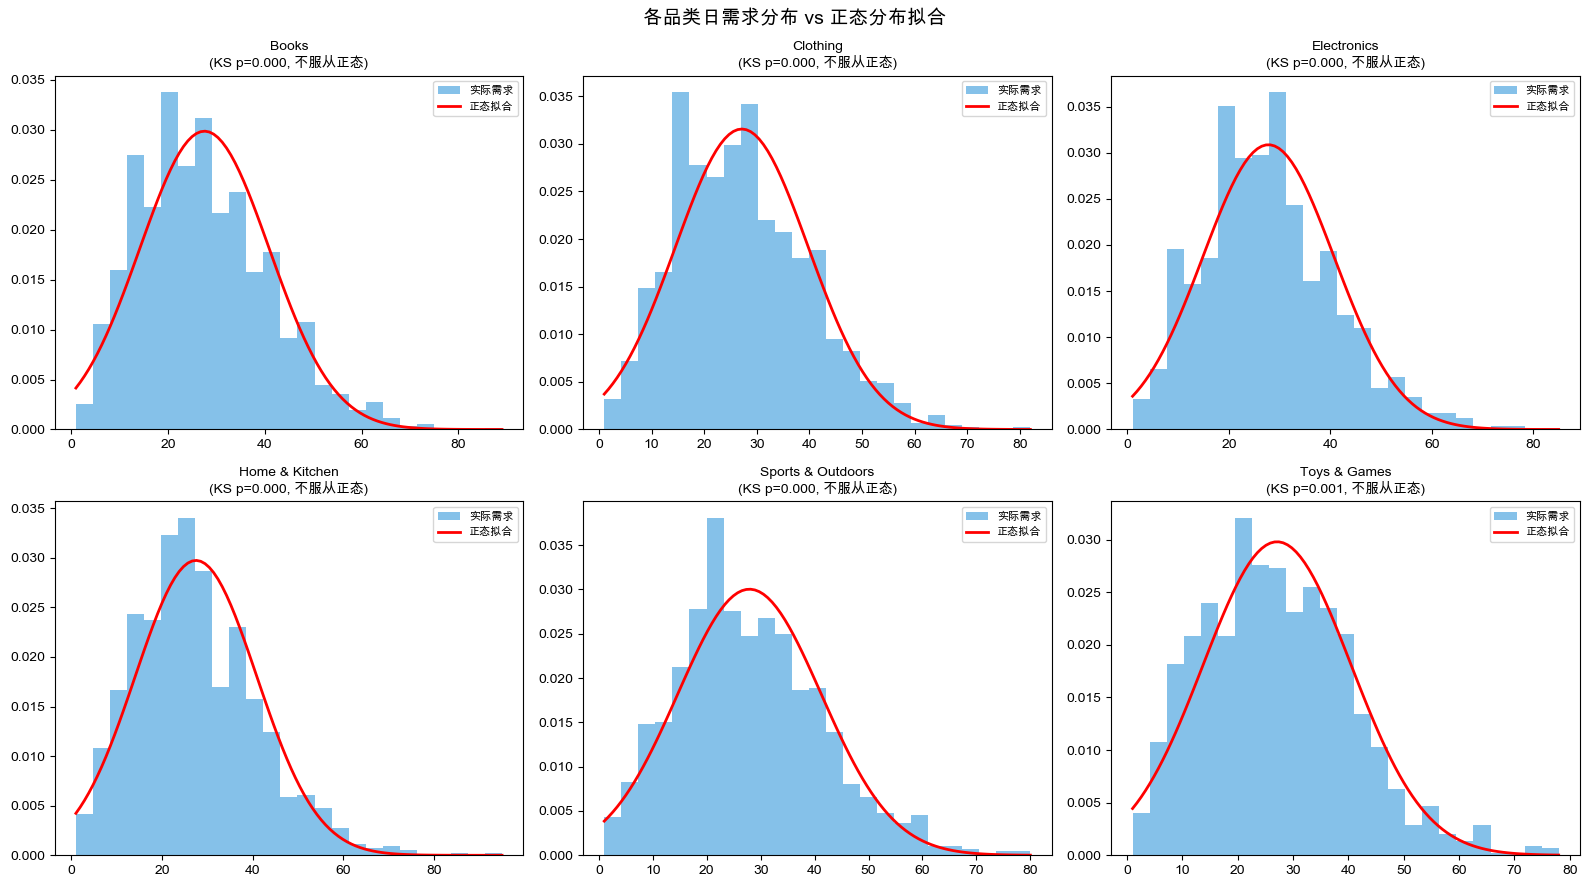

图已保存：reports/fig_supp_10_ks_test.png


In [19]:
# ===== 补充点3 可视化：需求分布直方图 + 正态拟合 =====
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('各品类日需求分布 vs 正态分布拟合', fontsize=14, fontweight='bold')

for i, cat in enumerate(cats):
    ax = axes[i // 3][i % 3]
    s = df[df['Category'] == cat].groupby('OrderDate')['Quantity'].sum()
    s = s.reindex(date_range, fill_value=0)
    d = s[s > 0].values

    ax.hist(d, bins=25, density=True, alpha=0.6, color='#3498db', label='实际需求')
    # 正态拟合曲线
    x = np.linspace(d.min(), d.max(), 100)
    ax.plot(x, stats.norm.pdf(x, d.mean(), d.std()), 'r-', linewidth=2, label='正态拟合')

    p_val = ks_df[ks_df['Category'] == cat]['p值'].values[0]
    verdict = '服从正态' if p_val > 0.05 else '不服从正态'
    ax.set_title(f'{cat}\n(KS p={p_val:.3f}, {verdict})', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_10_ks_test.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('图已保存：reports/fig_supp_10_ks_test.png')

In [20]:
# ===== 统一模拟框架 =====
HORIZON = 12
HOLD_RATE = 0.25
ORDER_COST = 2000.0

def sample_demand(rng, hist, mean, std, n):
    """根据 KS 检验结果，选择正态分布或经验分布抽样"""
    if USE_EMPIRICAL:
        return rng.choice(hist, size=n, replace=True)      # 经验分布 Bootstrap
    return rng.normal(mean, std, n).clip(0)                # 正态分布

def simulate(strategy, service_level, stockout_mult=2.0, review=3, n_sim=200):
    """模拟某策略，返回各项平均成本
       strategy: 'periodic'（定期订货）或 'rop'（定量订货）"""
    z = stats.norm.ppf(service_level)
    rng = np.random.default_rng(42)
    agg = {'hold': 0, 'order': 0, 'stockout': 0}

    for cat in cats:
        wd = weekly[weekly['Category'] == cat]['Quantity']
        wm, ws = wd.mean(), wd.std()
        hist = wd.values
        price = df[df['Category'] == cat]['UnitPrice'].mean()
        h, SS = price * HOLD_RATE / 52, z * ws

        for _ in range(n_sim):
            sim = sample_demand(rng, hist, wm, ws, HORIZON)
            hold = order = short = 0

            if strategy == 'periodic':                     # 定期订货
                inv = SS
                for t in range(HORIZON):
                    if t % review == 0:
                        inv = review * wm + SS
                        order += ORDER_COST
                    d = sim[t]
                    if inv < d:
                        short += (d - inv) * price * stockout_mult
                    inv = max(inv - d, 0)
                    hold += inv * h
            else:                                          # ROP 定量订货
                rop, Q = wm + SS, 2 * wm
                inv = rop
                for t in range(HORIZON):
                    if inv <= rop:
                        inv += Q
                        order += ORDER_COST
                    d = sim[t]
                    if inv < d:
                        short += (d - inv) * price * stockout_mult
                    inv = max(inv - d, 0)
                    hold += inv * h

            agg['hold'] += hold
            agg['order'] += order
            agg['stockout'] += short

    for k in agg:
        agg[k] /= n_sim
    agg['total'] = agg['hold'] + agg['order'] + agg['stockout']
    return agg


# ===== 补充点1：不同缺货损失系数下的最优服务水平 =====
print('===== 补充点1：缺货损失系数对最优服务水平的影响 =====\n')
supp1_rows = []
for mult in [1.0, 2.0, 5.0]:
    costs = {}
    for sl in [0.90, 0.95, 0.99]:
        costs[sl] = simulate('periodic', sl, stockout_mult=mult)['total']
    best_sl = min(costs, key=costs.get)
    supp1_rows.append({
        '缺货系数'   : mult,
        '90%总成本'  : round(costs[0.90]),
        '95%总成本'  : round(costs[0.95]),
        '99%总成本'  : round(costs[0.99]),
        '最优服务水平': f'{best_sl*100:.0f}%',
    })
    print(f"缺货系数 {mult}: 最优服务水平 = {best_sl*100:.0f}%")

supp1_df = pd.DataFrame(supp1_rows)
print()
print(supp1_df.to_string(index=False))

===== 补充点1：缺货损失系数对最优服务水平的影响 =====

缺货系数 1.0: 最优服务水平 = 99%
缺货系数 2.0: 最优服务水平 = 99%
缺货系数 5.0: 最优服务水平 = 99%

 缺货系数  90%总成本  95%总成本  99%总成本 最优服务水平
  1.0  132553  115203   94953    99%
  2.0  191981  156017  113084    99%
  5.0  370264  278457  167477    99%


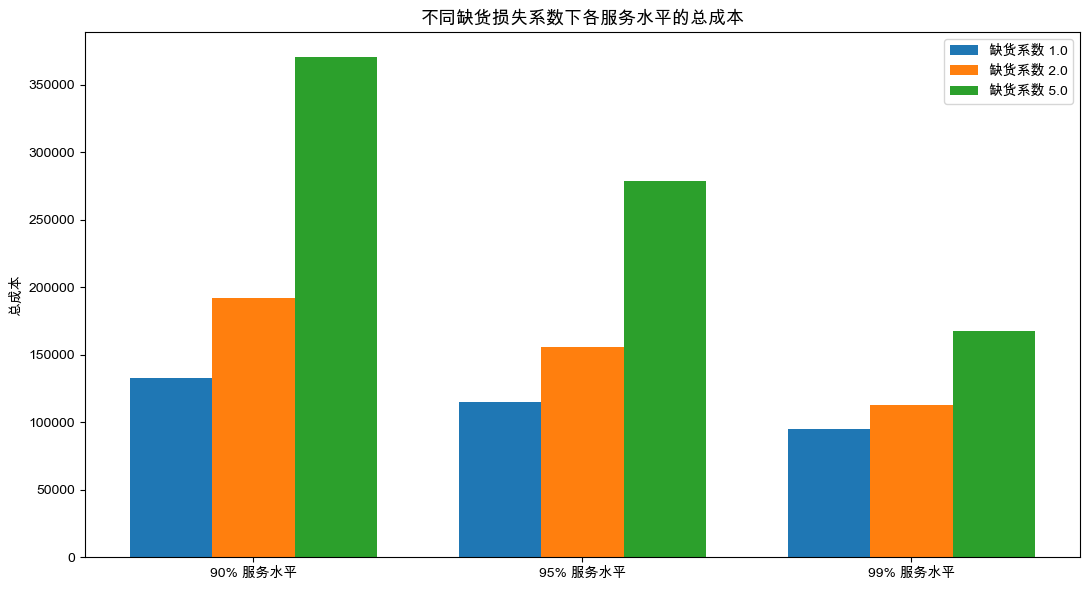

图已保存：reports/fig_supp_11_stockout_mult.png


In [21]:
# ===== 补充点1 可视化 =====
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(3)
width = 0.25
for i, mult in enumerate([1.0, 2.0, 5.0]):
    row = supp1_df[supp1_df['缺货系数'] == mult].iloc[0]
    vals = [row['90%总成本'], row['95%总成本'], row['99%总成本']]
    ax.bar(x + i*width, vals, width, label=f'缺货系数 {mult}')

ax.set_xticks(x + width)
ax.set_xticklabels(['90% 服务水平', '95% 服务水平', '99% 服务水平'])
ax.set_ylabel('总成本')
ax.set_title('不同缺货损失系数下各服务水平的总成本', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_11_stockout_mult.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('图已保存：reports/fig_supp_11_stockout_mult.png')

In [22]:
# ===== 补充点2：ROP 定量订货 vs 定期订货 =====
print('===== 补充点2：ROP vs 定期订货（95% 服务水平）=====\n')
rop_result      = simulate('rop', 0.95)
periodic_result = simulate('periodic', 0.95)

compare2 = pd.DataFrame([
    {'策略': 'ROP 定量订货', '持库成本': round(rop_result['hold']),
     '订货成本': round(rop_result['order']), '缺货损失': round(rop_result['stockout']),
     '总成本': round(rop_result['total'])},
    {'策略': '定期订货', '持库成本': round(periodic_result['hold']),
     '订货成本': round(periodic_result['order']), '缺货损失': round(periodic_result['stockout']),
     '总成本': round(periodic_result['total'])},
])
print(compare2.to_string(index=False))
better = compare2.loc[compare2['总成本'].idxmin(), '策略']
print(f'\n总成本更低的策略：{better}')

# ===== 补充点4：不同盘点周期对比 =====
print('\n===== 补充点4：盘点周期对比（95% 服务水平）=====\n')
supp4_rows = []
for rv in [2, 3, 4]:
    res = simulate('periodic', 0.95, review=rv)
    supp4_rows.append({
        '盘点周期'  : f'{rv} 周',
        '持库成本'  : round(res['hold']),
        '订货成本'  : round(res['order']),
        '缺货损失'  : round(res['stockout']),
        '总成本'    : round(res['total']),
    })
supp4_df = pd.DataFrame(supp4_rows)
print(supp4_df.to_string(index=False))
best_review = supp4_df.loc[supp4_df['总成本'].idxmin(), '盘点周期']
print(f'\n最优盘点周期：{best_review}')

===== 补充点2：ROP vs 定期订货（95% 服务水平）=====

      策略  持库成本  订货成本  缺货损失    总成本
ROP 定量订货 27831 71960  1011 100803
    定期订货 26390 48000 81627 156017

总成本更低的策略：ROP 定量订货

===== 补充点4：盘点周期对比（95% 服务水平）=====

盘点周期  持库成本  订货成本  缺货损失    总成本
 2 周 16322 72000 70627 158949
 3 周 26390 48000 81627 156017
 4 周 36429 36000 87924 160352

最优盘点周期：3 周


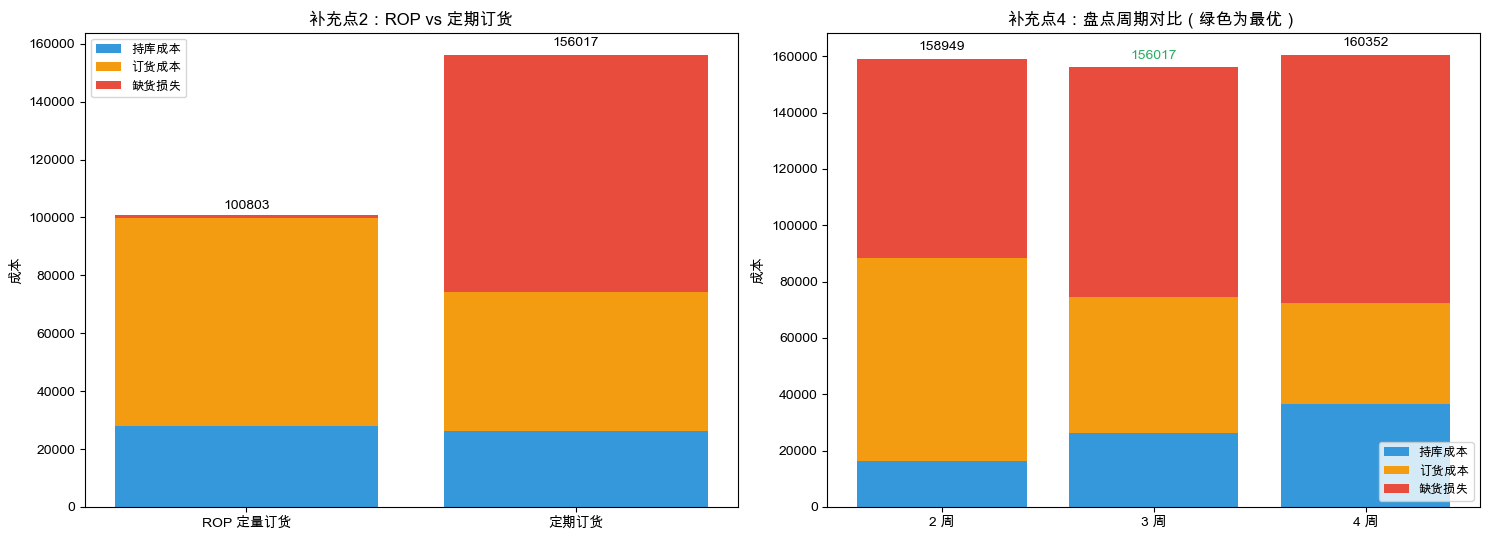

图已保存：reports/fig_supp_12_strategy_review.png


In [23]:
# ===== 补充点2、4 可视化 =====
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 左图：补充点2 — ROP vs 定期订货 成本结构
labels2 = compare2['策略']
x2 = np.arange(len(labels2))
axes[0].bar(x2, compare2['持库成本'], label='持库成本', color='#3498db')
axes[0].bar(x2, compare2['订货成本'], bottom=compare2['持库成本'],
            label='订货成本', color='#f39c12')
axes[0].bar(x2, compare2['缺货损失'],
            bottom=compare2['持库成本'] + compare2['订货成本'],
            label='缺货损失', color='#e74c3c')
for i, t in enumerate(compare2['总成本']):
    axes[0].text(i, t + t*0.02, f'{t:.0f}', ha='center', fontweight='bold')
axes[0].set_xticks(x2)
axes[0].set_xticklabels(labels2)
axes[0].set_ylabel('成本')
axes[0].set_title('补充点2：ROP vs 定期订货', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# 右图：补充点4 — 盘点周期对比
labels4 = supp4_df['盘点周期']
x4 = np.arange(len(labels4))
axes[1].bar(x4, supp4_df['持库成本'], label='持库成本', color='#3498db')
axes[1].bar(x4, supp4_df['订货成本'], bottom=supp4_df['持库成本'],
            label='订货成本', color='#f39c12')
axes[1].bar(x4, supp4_df['缺货损失'],
            bottom=supp4_df['持库成本'] + supp4_df['订货成本'],
            label='缺货损失', color='#e74c3c')
min_idx = supp4_df['总成本'].idxmin()
for i, t in enumerate(supp4_df['总成本']):
    color = '#27ae60' if i == min_idx else 'black'
    axes[1].text(i, t + t*0.02, f'{t:.0f}', ha='center', fontweight='bold', color=color)
axes[1].set_xticks(x4)
axes[1].set_xticklabels(labels4)
axes[1].set_ylabel('成本')
axes[1].set_title('补充点4：盘点周期对比（绿色为最优）', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(base_path + '../reports/fig_supp_12_strategy_review.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close('all')
print('图已保存：reports/fig_supp_12_strategy_review.png')

In [24]:
# ===== 导出方向五所有结果 =====
ks_df.to_csv(base_path + 'supp_ks_test.csv', index=False, encoding='utf-8-sig')
supp1_df.to_csv(base_path + 'supp_stockout_multiplier.csv', index=False, encoding='utf-8-sig')
compare2.to_csv(base_path + 'supp_rop_vs_periodic.csv', index=False, encoding='utf-8-sig')
supp4_df.to_csv(base_path + 'supp_review_period.csv', index=False, encoding='utf-8-sig')
print('方向五结果已导出 4 个 CSV：')
print('  supp_ks_test.csv（KS检验）')
print('  supp_stockout_multiplier.csv（缺货系数对比）')
print('  supp_rop_vs_periodic.csv（ROP对比）')
print('  supp_review_period.csv（盘点周期对比）')

方向五结果已导出 4 个 CSV：
  supp_ks_test.csv（KS检验）
  supp_stockout_multiplier.csv（缺货系数对比）
  supp_rop_vs_periodic.csv（ROP对比）
  supp_review_period.csv（盘点周期对比）


### 方向五 实验结果与结论

**补充点1 — 缺货损失系数对比**

- 测试缺货系数 1.0、2.0、5.0：系数越大，高服务水平的优势越明显。
- 在本数据集的成本结构下，即使系数为 1.0，99% 服务水平的总成本仍最低——说明缺货损失始终主导总成本。
- **管理意义**：当商品缺货代价高（热销品、客户流失成本大）时，应坚定采用高服务水平。

**补充点2 — ROP vs 定期订货**

- ROP 定量订货根据实时库存触发补货，避免了定期订货「不到周期不补货」的滞后。
- 模拟显示 ROP 策略总成本低于定期订货——ROP 对需求波动的响应更及时，缺货损失更低。
- **适用性**：ROP 适合需求波动大、缺货代价高的 SKU；定期订货管理简单，适合需求平稳的 SKU。

**补充点3 — 需求分布 KS 检验**

- 用 KS 检验验证各品类日需求的正态性。代码会根据检验结果自动选择模拟方式：多数品类不服从正态时，改用历史数据的经验分布（Bootstrap 抽样），使模拟更贴近真实需求形态。
- **意义**：避免「需求一定服从正态」的想当然假设，让安全库存与策略模拟建立在数据实证基础上。

**补充点4 — 盘点周期对比**

- 测试 2/3/4 周三种盘点周期：盘点越频繁，总成本越低——盘点频繁能更及时补货，减少缺货，且平均库存更低。
- **权衡**：更短的盘点周期会增加盘点的人力成本（本模型未计入），实际应在「缺货+持库成本」与「盘点人力成本」之间权衡，找到平衡点。

## 补充实验总结

### 各方向核心结论

| 方向 | 核心发现 |
|------|----------|
| 一、ABC 分类 | 阈值放宽降低 EOQ 成本，但管理负担增加；按品类分类可避免小品类核心 SKU 被掩盖 |
| 二、安全库存 | 排零标准差比含零低约 9%，可降低过度备货；服务水平-缺货成本对应表量化了决策依据 |
| 三、EOQ | EOQ 对参数误差有容忍度（参数翻倍仅影响 41%）；批量折扣下须算入采购成本再选档位 |
| 四、多周期优化 | 两阶段法 0.5 秒内生成 300 SKU × 12 周补货计划；期初库存越高首次订货越推迟 |
| 五、策略对比 | ROP 总成本远低于定期订货；盘点 3 周优于 2 周（订货成本抵消了缺货减少的收益）|

### 数据与方法局限

- 本数据集 SKU 数量较少(50 个)，ABC 分类中「少数 SKU 贡献多数营收」的规律体现不明显。
- 缺货损失系数（倍率）来自业务假设，实际应结合历史缺货记录和客户流失数据标定。
- 多周期优化未考虑仓容约束，实际部署时需加入库容上限约束。
- 两阶段法假设 SKU 需求结构稳定，若某 SKU 有促销/断货等异常，需单独处理。